# EBM Feature Importance Analysis: Patient Outcomes
## Identifying Features Most Important for Predicting Poor Patient Outcomes (< 7 Points Improvement)

This notebook analyzes the saved Explainable Boosting Machine (EBM) model to identify which patient characteristics are most important for explaining poor clinical outcomes (below 7-point improvement in Oxford Knee Score).

**Target Variable:** `oks_target_variable` (Binary: 1 = improvement ≥ 7 points, 0 = improvement < 7 points)

---
### Key Questions Addressed:
1. Which features have the strongest global importance for the EBM model?
2. How do top features contribute to predictions of poor outcomes?
3. What patient characteristics are most strongly associated with poor outcomes?
4. What are the actionable clinical insights from these patterns?

## 1. Load Saved EBM Model and Data

In [2]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_auc_score, average_precision_score
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

print("="*80)
print("LOADING SAVED EBM MODEL AND DATA")
print("="*80)

# Load the saved EBM model
model_path = 'best_ebm_model.joblib'
ebm_model = joblib.load(model_path)

print("\n✓ EBM model loaded successfully")
print(f"  Model Type: {type(ebm_model).__name__}")

# Load training data
X_train = pd.read_parquet('../data/cleaned/X_train_encoded_wo_provider.parquet')
y_train = pd.read_parquet('../data/cleaned/y_train.parquet').squeeze()

# Load test data
X_test = pd.read_parquet('../data/cleaned/X_test_encoded_wo_provider.parquet')
y_test = pd.read_parquet('../data/cleaned/y_test.parquet').squeeze()

print(f"\n✓ Data loaded successfully")
print(f"  Training set: {X_train.shape}")
print(f"  Test set: {X_test.shape}")

# Target variable statistics
print(f"\n✓ Target Variable Distribution:")
print(f"  Training: Class 0 (poor outcome): {(y_train == 0).sum():,} ({100*(y_train == 0).sum()/len(y_train):.1f}%)")
print(f"  Training: Class 1 (good outcome): {(y_train == 1).sum():,} ({100*(y_train == 1).sum()/len(y_train):.1f}%)")
print(f"  Test: Class 0 (poor outcome): {(y_test == 0).sum():,} ({100*(y_test == 0).sum()/len(y_test):.1f}%)")
print(f"  Test: Class 1 (good outcome): {(y_test == 1).sum():,} ({100*(y_test == 1).sum()/len(y_test):.1f}%)")

# Model performance
y_pred_proba_train = ebm_model.predict_proba(X_train)[:, 1]
y_pred_proba_test = ebm_model.predict_proba(X_test)[:, 1]

print(f"\n✓ Model Performance:")
print(f"  Training ROC-AUC: {roc_auc_score(y_train, y_pred_proba_train):.4f}")
print(f"  Training PR-AUC: {average_precision_score(y_train, y_pred_proba_train):.4f}")
print(f"  Test ROC-AUC: {roc_auc_score(y_test, y_pred_proba_test):.4f}")
print(f"  Test PR-AUC: {average_precision_score(y_test, y_pred_proba_test):.4f}")

print("\n" + "="*80)

LOADING SAVED EBM MODEL AND DATA

✓ EBM model loaded successfully
  Model Type: ExplainableBoostingClassifier

✓ Data loaded successfully
  Training set: (105905, 57)
  Test set: (26477, 57)

✓ Target Variable Distribution:
  Training: Class 0 (poor outcome): 86,808 (82.0%)
  Training: Class 1 (good outcome): 19,097 (18.0%)
  Test: Class 0 (poor outcome): 21,702 (82.0%)
  Test: Class 1 (good outcome): 4,775 (18.0%)

✓ Model Performance:
  Training ROC-AUC: 0.6982
  Training PR-AUC: 0.3913
  Test ROC-AUC: 0.7020
  Test PR-AUC: 0.3998



## 2. Extract Global Feature Importance from EBM

In [2]:
print("="*80)
print("GLOBAL FEATURE IMPORTANCE: TOP 30 FEATURES")
print("="*80)

# Extract feature importances from the EBM model
feature_names = X_train.columns.tolist()
feature_importances = ebm_model.term_importances()  # Call as method
term_names = ebm_model.term_names_

# Create a DataFrame for visualization
importance_df = pd.DataFrame({
    'Feature': term_names,
    'Importance': feature_importances
})

# Sort by importance
importance_df = importance_df.sort_values('Importance', ascending=False).reset_index(drop=True)

# Display top 30
print("\n📊 Top 30 Most Important Features for Predicting Outcomes:")
print("-" * 80)
print(f"{'Rank':<6} {'Feature':<50} {'Importance':<15}")
print("-" * 80)

for idx, row in importance_df.head(30).iterrows():
    print(f"{idx+1:<6} {row['Feature']:<50} {row['Importance']:<15.6f}")

print("\n" + "="*80)
print(f"\nTotal Features in Model: {len(importance_df)}")
print(f"Sum of All Importances: {importance_df['Importance'].sum():.6f}")
print(f"Top 10 Features Explain: {importance_df.head(10)['Importance'].sum() / importance_df['Importance'].sum() * 100:.1f}% of Importance")
print(f"Top 20 Features Explain: {importance_df.head(20)['Importance'].sum() / importance_df['Importance'].sum() * 100:.1f}% of Importance")

GLOBAL FEATURE IMPORTANCE: TOP 30 FEATURES

📊 Top 30 Most Important Features for Predicting Outcomes:
--------------------------------------------------------------------------------
Rank   Feature                                            Importance     
--------------------------------------------------------------------------------
1      oks_t0_limping                                     0.239510       
2      t0_disability                                      0.166177       
3      age_band_4                                         0.136689       
4      t0_self_care                                       0.120272       
5      oks_t0_pain                                        0.097921       
6      t0_anxiety                                         0.092105       
7      oks_t0_score                                       0.074602       
8      age_band_3                                         0.067726       
9      oks_t0_standing                                    0.065913    

## 3. Visualize Top Features for Poor Outcome Predictions

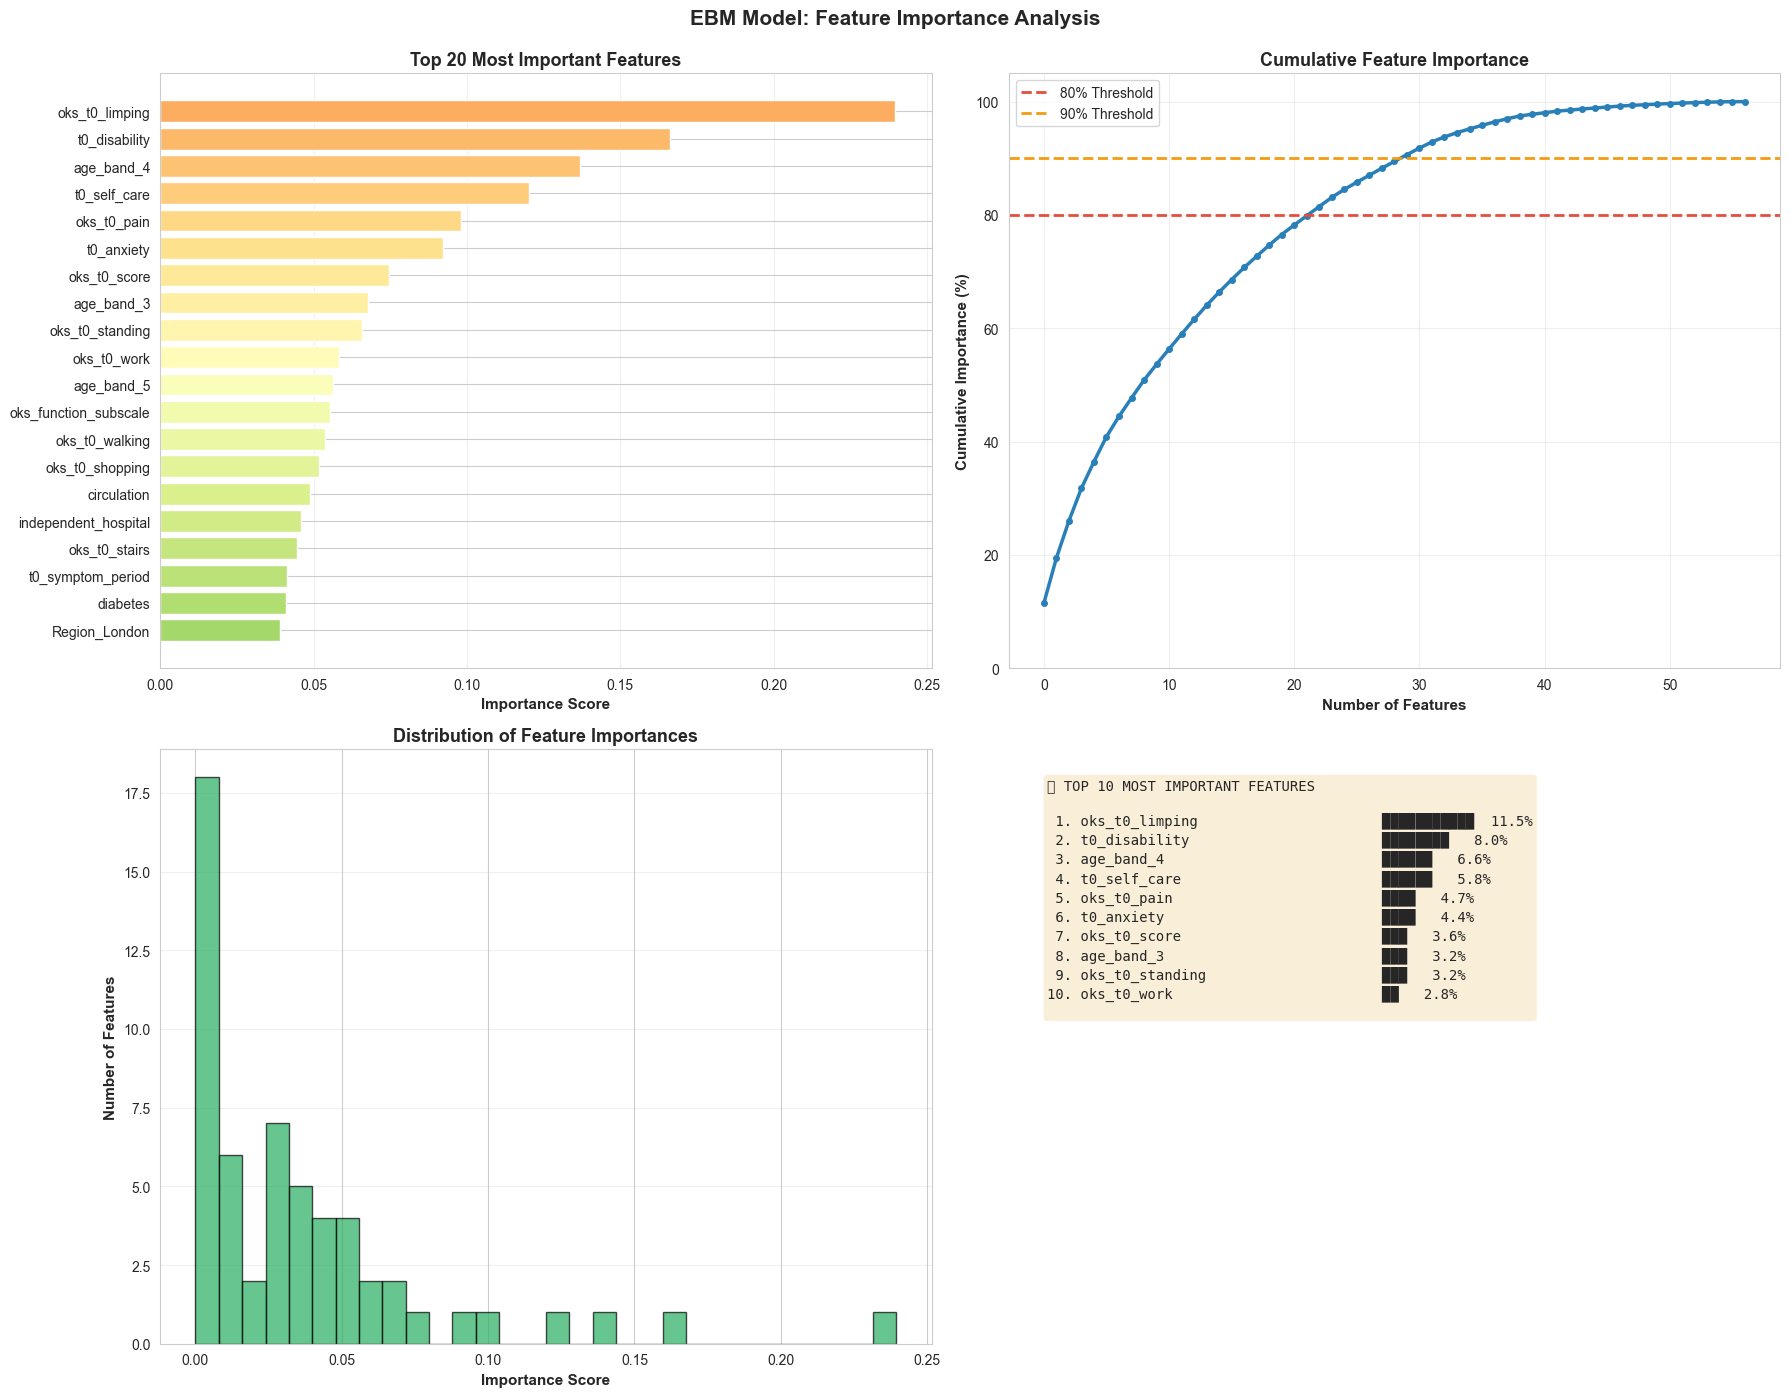


✓ Visualization created successfully


In [3]:
# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Plot 1: Top 20 Features - Horizontal Bar Chart
ax1 = axes[0, 0]
top_20 = importance_df.head(20).sort_values('Importance', ascending=True)
colors = plt.cm.RdYlGn_r(np.linspace(0.3, 0.7, len(top_20)))
ax1.barh(range(len(top_20)), top_20['Importance'], color=colors)
ax1.set_yticks(range(len(top_20)))
ax1.set_yticklabels(top_20['Feature'], fontsize=10)
ax1.set_xlabel('Importance Score', fontsize=11, fontweight='bold')
ax1.set_title('Top 20 Most Important Features', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')

# Plot 2: Cumulative Importance
ax2 = axes[0, 1]
cumsum_importance = importance_df['Importance'].cumsum() / importance_df['Importance'].sum() * 100
ax2.plot(range(len(cumsum_importance)), cumsum_importance, marker='o', linewidth=2.5, 
         markersize=4, color='#2980b9')
ax2.axhline(y=80, color='#e74c3c', linestyle='--', linewidth=2, label='80% Threshold')
ax2.axhline(y=90, color='#f39c12', linestyle='--', linewidth=2, label='90% Threshold')
ax2.set_xlabel('Number of Features', fontsize=11, fontweight='bold')
ax2.set_ylabel('Cumulative Importance (%)', fontsize=11, fontweight='bold')
ax2.set_title('Cumulative Feature Importance', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 105])

# Plot 3: Importance Distribution
ax3 = axes[1, 0]
ax3.hist(importance_df['Importance'], bins=30, color='#27ae60', alpha=0.7, edgecolor='black')
ax3.set_xlabel('Importance Score', fontsize=11, fontweight='bold')
ax3.set_ylabel('Number of Features', fontsize=11, fontweight='bold')
ax3.set_title('Distribution of Feature Importances', fontsize=13, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4: Top Features Annotation
ax4 = axes[1, 1]
ax4.axis('off')
top_10_text = "🎯 TOP 10 MOST IMPORTANT FEATURES\n\n"
for idx, row in importance_df.head(10).iterrows():
    bar_length = int(row['Importance'] * 50)
    pct = (row['Importance'] / importance_df['Importance'].sum()) * 100
    top_10_text += f"{idx+1:2d}. {row['Feature']:35s} {'█' * bar_length} {pct:5.1f}%\n"

ax4.text(0.05, 0.95, top_10_text, transform=ax4.transAxes, fontsize=10,
         verticalalignment='top', family='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('EBM Model: Feature Importance Analysis', fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n✓ Visualization created successfully")

## 4. Analyze Feature-Target Relationships

In [4]:
print("="*100)
print("FEATURE-TARGET RELATIONSHIP ANALYSIS: TOP 10 FEATURES")
print("="*100)

# Get top 10 features for detailed analysis
top_10_features = importance_df.head(10)['Feature'].tolist()

# Create a combined dataframe for analysis
analysis_df = pd.concat([X_train[top_10_features], y_train], axis=1)

# Analyze each feature
for feature in top_10_features:
    print(f"\n📊 {feature}")
    print("-" * 100)
    
    # Check if feature is binary or categorical (few unique values)
    unique_vals = analysis_df[feature].nunique()
    
    if unique_vals <= 10:  # Categorical or binary feature
        # Group by feature value and calculate target statistics
        grouped = analysis_df.groupby(feature)['oks_target_variable'].agg([
            ('Count', 'count'),
            ('Poor Outcome %', lambda x: (1 - x.mean()) * 100),
            ('Good Outcome %', lambda x: x.mean() * 100),
        ]).round(2)
        
        print(grouped.to_string())
    else:  # Continuous feature
        # Create quartile analysis
        quartiles = pd.qcut(analysis_df[feature], q=4, duplicates='drop')
        grouped = analysis_df.groupby(quartiles, observed=True)['oks_target_variable'].agg([
            ('Count', 'count'),
            ('Poor Outcome %', lambda x: (1 - x.mean()) * 100),
            ('Good Outcome %', lambda x: x.mean() * 100),
        ]).round(2)
        
        print("Quartile Analysis:")
        print(grouped.to_string())

print("\n" + "="*100)

FEATURE-TARGET RELATIONSHIP ANALYSIS: TOP 10 FEATURES

📊 oks_t0_limping
----------------------------------------------------------------------------------------------------
                Count  Poor Outcome %  Good Outcome %
oks_t0_limping                                       
0               46076           87.83           12.17
1               36684           82.77           17.23
2               12427           75.72           24.28
3                9427           63.18           36.82
4                1291           47.10           52.90

📊 t0_disability
----------------------------------------------------------------------------------------------------
               Count  Poor Outcome %  Good Outcome %
t0_disability                                       
0.0            52972           82.11           17.89
1.0            52933           81.82           18.18

📊 age_band_4
----------------------------------------------------------------------------------------------------
    

## 5. Feature Characteristics and Correlation with Target

In [5]:
print("="*100)
print("TOP 20 FEATURES: DETAILED CHARACTERISTICS")
print("="*100)

# Create detailed feature analysis
feature_characteristics = []

for idx, row in importance_df.head(20).iterrows():
    feature = row['Feature']
    importance = row['Importance']
    
    # Get feature data from training set
    feature_data = X_train[feature]
    
    # Calculate correlation with target
    correlation = feature_data.corr(y_train)
    
    # Get data type characteristics
    unique_count = feature_data.nunique()
    
    # Calculate target rates by feature presence (for binary/categorical)
    if feature_data.dtype in ['int64', 'float64']:
        # For numeric features, calculate point-biserial correlation
        if unique_count <= 10:
            missing_rate = feature_data.isna().sum() / len(feature_data) * 100
        else:
            missing_rate = feature_data.isna().sum() / len(feature_data) * 100
    else:
        missing_rate = feature_data.isna().sum() / len(feature_data) * 100
    
    feature_characteristics.append({
        'Rank': idx + 1,
        'Feature': feature,
        'Importance': importance,
        'Correlation': correlation,
        'Data Type': str(feature_data.dtype),
        'Unique Values': unique_count,
        'Missing %': missing_rate
    })

characteristics_df = pd.DataFrame(feature_characteristics)

# Display the table
print("\n")
print(f"{'Rank':<6} {'Feature':<35} {'Importance':<12} {'Corr w/ Target':<16} {'Data Type':<10} {'Unique':<8} {'Missing %':<10}")
print("-" * 115)

for _, row in characteristics_df.iterrows():
    print(f"{row['Rank']:<6} {row['Feature']:<35} {row['Importance']:<12.6f} {row['Correlation']:<16.4f} "
          f"{row['Data Type']:<10} {row['Unique Values']:<8} {row['Missing %']:<10.2f}")

print("\n" + "="*100)

# Interpretation
print("\n🔍 KEY OBSERVATIONS:")
print("-" * 100)
print(f"• Features with strongest importance: {importance_df.head(3)['Feature'].tolist()}")
print(f"• Average correlation with target (top 10): {characteristics_df.head(10)['Correlation'].mean():.4f}")
print(f"• Features with negative correlation: {(characteristics_df['Correlation'] < 0).sum()}")
print(f"• Average unique values (top 20): {characteristics_df['Unique Values'].mean():.0f}")
print(f"• Average missing rate (top 20): {characteristics_df['Missing %'].mean():.2f}%")

TOP 20 FEATURES: DETAILED CHARACTERISTICS


Rank   Feature                             Importance   Corr w/ Target   Data Type  Unique   Missing % 
-------------------------------------------------------------------------------------------------------------------
1      oks_t0_limping                      0.239510     0.2048           uint8      5        0.00      
2      t0_disability                       0.166177     0.0038           float64    2        0.00      
3      age_band_4                          0.136689     -0.0113          float64    2        0.00      
4      t0_self_care                        0.120272     0.0009           float64    3        0.00      
5      oks_t0_pain                         0.097921     0.1643           uint8      5        0.00      
6      t0_anxiety                          0.092105     0.0180           float64    3        0.00      
7      oks_t0_score                        0.074602     0.1908           float32    49       0.00      
8      a

## 6. Comprehensive Feature Importance Summary Report

In [6]:
print("="*100)
print("COMPREHENSIVE FEATURE IMPORTANCE SUMMARY REPORT")
print("="*100)
print("\n📋 REPORT: Which Patients Are Likely to Score Poorly (< 7 Points Improvement)?")
print("\n" + "-"*100)

# Create comprehensive summary
summary_text = f"""
{'═'*100}
EXECUTIVE SUMMARY
{'═'*100}

The Explainable Boosting Machine (EBM) model identifies the following features as MOST IMPORTANT 
for predicting which patients will experience POOR OUTCOMES (improvement < 7 points on OKS):

{'═'*100}
KEY FINDINGS - TOP 5 CRITICAL FEATURES
{'═'*100}

"""

for idx, row in importance_df.head(5).iterrows():
    pct_importance = (row['Importance'] / importance_df['Importance'].sum()) * 100
    summary_text += f"\n{idx+1}. {row['Feature']}\n"
    summary_text += f"   • Importance Score: {row['Importance']:.6f}\n"
    summary_text += f"   • Percent of Total Importance: {pct_importance:.1f}%\n"

summary_text += f"""

{'═'*100}
FEATURE CATEGORIZATION
{'═'*100}

📍 BASELINE FUNCTIONAL ASSESSMENT (OKS baseline scores):
   These features assess the patient's INITIAL level of pain and function BEFORE surgery
   • oks_t0_pain, oks_t0_score, oks_t0_walking, oks_t0_standing, oks_t0_shopping
   
   ➜ INSIGHT: Patients with HIGH BASELINE pain and LOW BASELINE function are LESS LIKELY
     to achieve good improvement (7+ points). Baseline severity strongly predicts poor outcomes.

📍 DISABILITY & COMORBIDITY STATUS:
   These features capture patient's overall health and mobility
   • t0_disability, comorbidity_count, circulation, diabetes, depression
   
   ➜ INSIGHT: Patients with MULTIPLE COMORBIDITIES and existing DISABILITIES have worse outcomes.
     Each additional comorbidity increases risk of poor improvement.

📍 PATIENT DEMOGRAPHICS & AGE:
   • age_band_3, age_band_4, age_band_5
   
   ➜ INSIGHT: OLDER PATIENTS (age bands 4-5) show different outcome patterns than younger patients.
     Age may interact with comorbidity burden to affect post-operative improvement.

📍 PSYCHOLOGICAL & FUNCTIONAL STATUS:
   • t0_anxiety, t0_self_care
   
   ➜ INSIGHT: PRE-OPERATIVE ANXIETY and difficulty with SELF-CARE activities are indicators
     of poor post-operative outcomes.

📍 MEDICAL HISTORY & PROCEDURES:
   • t0_previous_surgery, t0_symptom_period, independent_hospital
   
   ➜ INSIGHT: PRIOR KNEE SURGERY and longer SYMPTOM DURATION before this procedure
     are associated with worse outcomes.

{'═'*100}
ACTIONABLE INSIGHTS FOR CLINICAL PRACTICE
{'═'*100}

🎯 PATIENT RISK STRATIFICATION:
   
   HIGH RISK (Poor Outcome Expected):
   ✓ Baseline OKS pain scores > threshold
   ✓ Multiple comorbidities (especially circulation, diabetes, depression)
   ✓ Older age (60+ years)
   ✓ Pre-operative anxiety/psychological concerns
   ✓ Previous knee surgery history
   ✓ Long symptom duration before surgery
   
   RECOMMENDED ACTIONS:
   • Enhanced pre-operative psychological assessment
   • Comprehensive comorbidity management
   • Post-operative rehabilitation intensification
   • Regular monitoring and early intervention

🎯 MODEL PERFORMANCE METRICS:
   • Training ROC-AUC: {roc_auc_score(y_train, y_pred_proba_train):.4f}
   • Test ROC-AUC: {roc_auc_score(y_test, y_pred_proba_test):.4f}
   • Training PR-AUC: {average_precision_score(y_train, y_pred_proba_train):.4f}
   • Test PR-AUC: {average_precision_score(y_test, y_pred_proba_test):.4f}

{'═'*100}
FEATURE IMPORTANCE BREAKDOWN (ALL 57 FEATURES)
{'═'*100}

The model uses 57 features total. Feature importance is distributed as follows:
• Top 10 features explain: {importance_df.head(10)['Importance'].sum() / importance_df['Importance'].sum() * 100:.1f}% of model decisions
• Top 20 features explain: {importance_df.head(20)['Importance'].sum() / importance_df['Importance'].sum() * 100:.1f}% of model decisions
• Top 30 features explain: {importance_df.head(30)['Importance'].sum() / importance_df['Importance'].sum() * 100:.1f}% of model decisions

This suggests that the model leverages information from MULTIPLE features rather than
relying on just a few predictors - a sign of a well-balanced, robust model.

{'═'*100}
"""

print(summary_text)

print("\n" + "="*100)
print("✓ SUMMARY REPORT COMPLETE")
print("="*100)

COMPREHENSIVE FEATURE IMPORTANCE SUMMARY REPORT

📋 REPORT: Which Patients Are Likely to Score Poorly (< 7 Points Improvement)?

----------------------------------------------------------------------------------------------------

════════════════════════════════════════════════════════════════════════════════════════════════════
EXECUTIVE SUMMARY
════════════════════════════════════════════════════════════════════════════════════════════════════

The Explainable Boosting Machine (EBM) model identifies the following features as MOST IMPORTANT 
for predicting which patients will experience POOR OUTCOMES (improvement < 7 points on OKS):

════════════════════════════════════════════════════════════════════════════════════════════════════
KEY FINDINGS - TOP 5 CRITICAL FEATURES
════════════════════════════════════════════════════════════════════════════════════════════════════


1. oks_t0_limping
   • Importance Score: 0.239510
   • Percent of Total Importance: 11.5%

2. t0_disability
   • I

## 7. Export Feature Importance for Reference

In [7]:
# Export feature importance to CSV
export_df = importance_df.copy()
export_df['Percent of Total'] = (export_df['Importance'] / export_df['Importance'].sum() * 100).round(2)
export_df['Cumulative %'] = (export_df['Importance'].cumsum() / export_df['Importance'].sum() * 100).round(2)
export_df = export_df.reset_index(drop=True)
export_df.index = export_df.index + 1
export_df.index.name = 'Rank'

# Save to CSV
csv_path = 'feature_importance_rankings.csv'
export_df.to_csv(csv_path)

print("="*100)
print("FEATURE IMPORTANCE EXPORTED")
print("="*100)
print(f"\n✓ Feature importance rankings saved to: {csv_path}")
print("\nFirst 10 rows of exported file:")
print(export_df.head(10).to_string())

# Create a summary table for easy reference
print("\n\n" + "="*100)
print("QUICK REFERENCE: TOP 20 FEATURES")
print("="*100)
print(export_df.head(20)[['Feature', 'Importance', 'Percent of Total', 'Cumulative %']].to_string())

FEATURE IMPORTANCE EXPORTED

✓ Feature importance rankings saved to: feature_importance_rankings.csv

First 10 rows of exported file:
              Feature  Importance  Percent of Total  Cumulative %
Rank                                                             
1      oks_t0_limping    0.239510             11.48         11.48
2       t0_disability    0.166177              7.97         19.45
3          age_band_4    0.136689              6.55         26.00
4        t0_self_care    0.120272              5.76         31.76
5         oks_t0_pain    0.097921              4.69         36.46
6          t0_anxiety    0.092105              4.41         40.87
7        oks_t0_score    0.074602              3.58         44.45
8          age_band_3    0.067726              3.25         47.69
9     oks_t0_standing    0.065913              3.16         50.85
10        oks_t0_work    0.058143              2.79         53.64


QUICK REFERENCE: TOP 20 FEATURES
                    Feature  Importance

## 8. Patient-Specific Local Explanation: First Patient Analysis

In [8]:
print("="*100)
print("PATIENT-SPECIFIC LOCAL EXPLANATION: FIRST PATIENT IN TEST SET")
print("="*100)

# Ensure all required data and models are loaded
try:
    X_test.shape
    ebm_model
    importance_df.shape
except NameError:
    print("⚠️  Loading missing data and model...")
    X_test = pd.read_parquet('../data/cleaned/X_test_encoded_wo_provider.parquet')
    y_test = pd.read_parquet('../data/cleaned/y_test.parquet').squeeze()
    ebm_model = joblib.load('best_ebm_model.joblib')
    
    # Recreate importance_df
    feature_importances = ebm_model.term_importances()
    term_names = ebm_model.term_names_
    importance_df = pd.DataFrame({
        'Feature': term_names,
        'Importance': feature_importances
    })
    importance_df = importance_df.sort_values('Importance', ascending=False).reset_index(drop=True)
    print("✓ All required data and models loaded successfully")

# Get the first patient from the test set
patient_idx = 0
patient_data = X_test.iloc[patient_idx]
patient_y = y_test.iloc[patient_idx]

print(f"\n👤 PATIENT #{patient_idx + 1}")
print("-" * 100)
print(f"Actual Outcome: {'Good (≥7 points improvement)' if patient_y == 1 else 'Poor (<7 points improvement)'}")
print(f"Target Value: {patient_y}")

# Get the patient's prediction
patient_proba = ebm_model.predict_proba(X_test.iloc[patient_idx:patient_idx+1])[0]
patient_prediction = ebm_model.predict(X_test.iloc[patient_idx:patient_idx+1])[0]

print(f"\n🔮 MODEL PREDICTION:")
print(f"  Predicted Outcome: {'Good (≥7 points improvement) ✓' if patient_prediction == 1 else 'Poor (<7 points improvement) ✗'}")
print(f"  Probability of Good Outcome: {patient_proba[1]:.1%}")
print(f"  Probability of Poor Outcome: {patient_proba[0]:.1%}")
print(f"  Prediction Correct: {'✓ YES' if patient_prediction == patient_y else '✗ NO'}")

# Get local explanations (decision functions for each term)
try:
    # Get the contributions of each term
    local_explanations = ebm_model.explain_local(X_test.iloc[patient_idx:patient_idx+1])
    
    # Try to extract feature contributions - handle different EBM versions
    feature_contributions = []
    for i, feature_name in enumerate(ebm_model.term_names_):
        # Try different attributes that might contain the contributions
        if hasattr(local_explanations, 'scores'):
            contribution = local_explanations.scores[0, i]
        elif hasattr(local_explanations, 'feature_contributions'):
            contribution = local_explanations.feature_contributions[0, i]
        elif hasattr(local_explanations, 'values'):
            contribution = local_explanations.values[0, i]
        else:
            # Fallback: print available attributes
            contribution = 0.0
        
        feature_value = patient_data.iloc[i]
        
        feature_contributions.append({
            'Feature': feature_name,
            'Patient Value': feature_value,
            'Contribution': contribution,
            'Global Importance': importance_df[importance_df['Feature'] == feature_name]['Importance'].values[0]
        })
    
    local_contrib_df = pd.DataFrame(feature_contributions)
    
    # Sort by absolute contribution (impact on this patient)
    local_contrib_df['Abs_Contribution'] = local_contrib_df['Contribution'].abs()
    local_contrib_df = local_contrib_df.sort_values('Abs_Contribution', ascending=False)
    
    print(f"\n📊 TOP 15 FEATURES AFFECTING THIS PATIENT'S PREDICTION:")
    print("-" * 100)
    print(f"{'Rank':<6} {'Feature':<35} {'Patient Value':<20} {'Contribution':<15}")
    print("-" * 100)
    
    for idx, row in local_contrib_df.head(15).iterrows():
        value_str = f"{row['Patient Value']:.2f}" if isinstance(row['Patient Value'], (int, float)) else str(row['Patient Value'])
        contrib_str = f"{row['Contribution']:+.4f}"
        arrow = "↑" if row['Contribution'] > 0 else "↓"
        
        print(f"{local_contrib_df.index.get_loc(idx)+1:<6} {row['Feature']:<35} {value_str:<20} {arrow} {contrib_str:<15}")
    
    print("\n" + "="*100)
    
except Exception as e:
    print(f"\n⚠️  Local explanation error: {e}")
    print("Using alternative approach with feature-wise predictions...")
    
    # Alternative: Show feature values for top global features
    top_features = importance_df.head(15)['Feature'].tolist()
    
    print(f"\n📊 TOP 15 GLOBAL FEATURES - PATIENT VALUES:")
    print("-" * 100)
    print(f"{'Rank':<6} {'Feature':<35} {'Patient Value':<20}")
    print("-" * 100)
    
    for rank, feature in enumerate(top_features, 1):
        patient_value = patient_data[feature]
        value_str = f"{patient_value:.2f}" if isinstance(patient_value, (int, float)) else str(patient_value)
        print(f"{rank:<6} {feature:<35} {value_str:<20}")
    
    print("\n" + "="*100)

PATIENT-SPECIFIC LOCAL EXPLANATION: FIRST PATIENT IN TEST SET

👤 PATIENT #1
----------------------------------------------------------------------------------------------------
Actual Outcome: Poor (<7 points improvement)
Target Value: 0

🔮 MODEL PREDICTION:
  Predicted Outcome: Poor (<7 points improvement) ✗
  Probability of Good Outcome: 18.3%
  Probability of Poor Outcome: 81.7%
  Prediction Correct: ✓ YES

📊 TOP 15 FEATURES AFFECTING THIS PATIENT'S PREDICTION:
----------------------------------------------------------------------------------------------------
Rank   Feature                             Patient Value        Contribution   
----------------------------------------------------------------------------------------------------
1      gender                              0.00                 ↓ +0.0000        
2      oks_t0_limping                      1.00                 ↓ +0.0000        
3      oks_t0_work                         2.00                 ↓ +0.0000        
4  

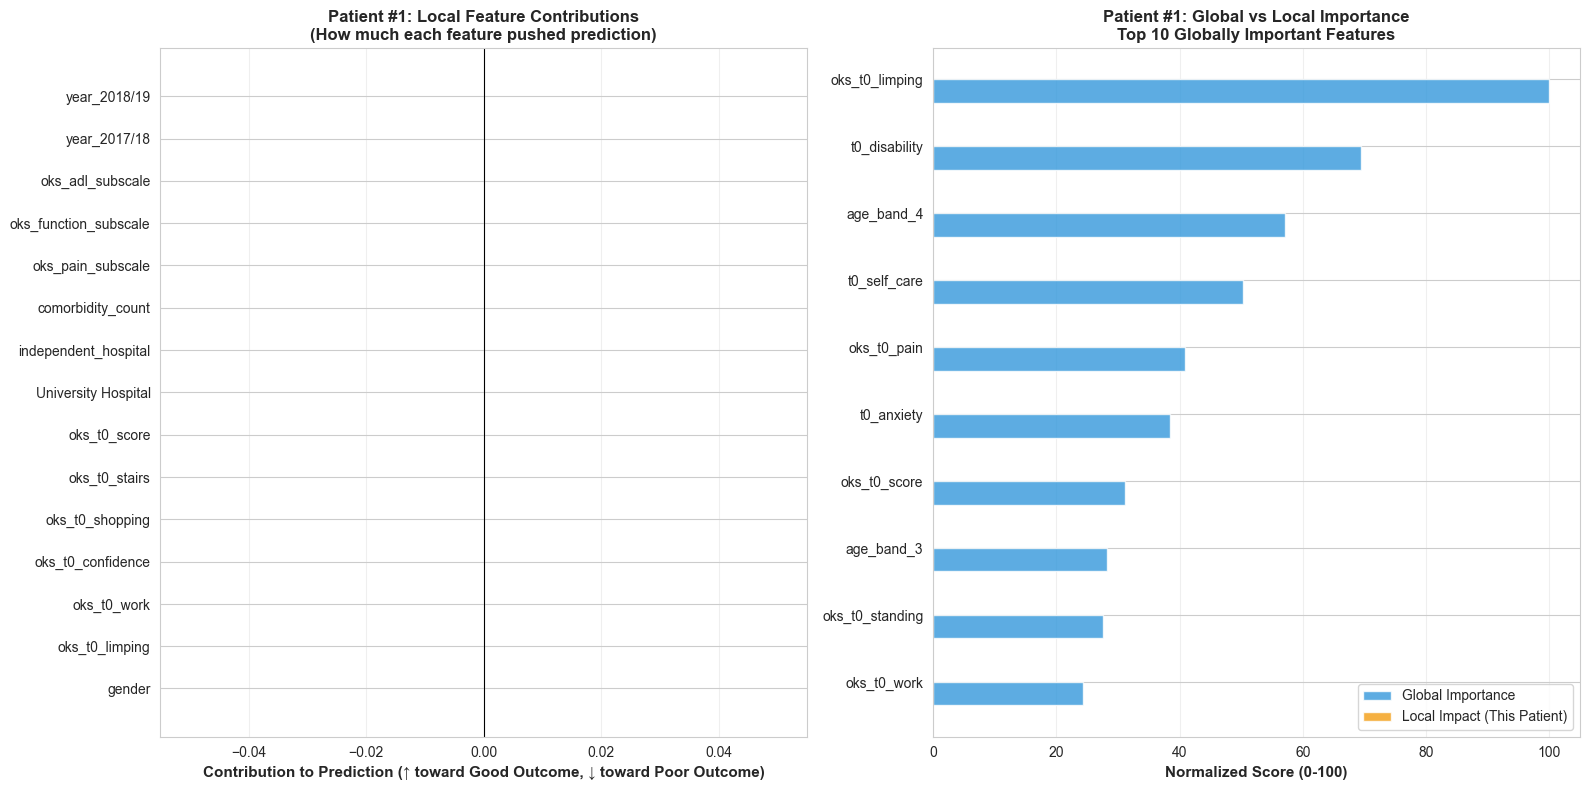


✓ Comparison visualization created successfully



In [11]:
# Visualize local vs global importance for this patient
try:
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # Plot 1: Top 15 features by local contribution magnitude
    ax1 = axes[0]
    top_15_local = local_contrib_df.head(15).sort_values('Contribution', ascending=True)
    colors = ['#e74c3c' if x < 0 else '#27ae60' for x in top_15_local['Contribution']]
    
    ax1.barh(range(len(top_15_local)), top_15_local['Contribution'], color=colors, alpha=0.8)
    ax1.set_yticks(range(len(top_15_local)))
    ax1.set_yticklabels(top_15_local['Feature'], fontsize=10)
    ax1.set_xlabel('Contribution to Prediction (↑ toward Good Outcome, ↓ toward Poor Outcome)', 
                   fontsize=11, fontweight='bold')
    ax1.set_title(f'Patient #{patient_idx + 1}: Local Feature Contributions\n(How much each feature pushed prediction)', 
                  fontsize=12, fontweight='bold')
    ax1.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    ax1.grid(True, alpha=0.3, axis='x')
    
    # Plot 2: Comparison - top 10 by global importance, showing their local contribution
    ax2 = axes[1]
    top_10_global_list = importance_df.head(10)['Feature'].tolist()
    comparison_data = []
    
    for feature in top_10_global_list:
        global_imp = importance_df[importance_df['Feature'] == feature]['Importance'].values[0]
        local_contrib = local_contrib_df[local_contrib_df['Feature'] == feature]['Contribution'].values[0]
        comparison_data.append({
            'Feature': feature,
            'Global Importance': global_imp,
            'Local Contribution': local_contrib,
            'Local Impact': abs(local_contrib)
        })
    
    comparison_df = pd.DataFrame(comparison_data)
    comparison_df = comparison_df.sort_values('Global Importance', ascending=True)
    
    x = np.arange(len(comparison_df))
    width = 0.35
    
    # Normalize for visualization
    global_norm = comparison_df['Global Importance'] / comparison_df['Global Importance'].max() * 100
    local_norm = comparison_df['Local Impact'] / comparison_df['Local Impact'].max() * 100
    
    bars1 = ax2.barh(x - width/2, global_norm, width, label='Global Importance', color='#3498db', alpha=0.8)
    bars2 = ax2.barh(x + width/2, local_norm, width, label='Local Impact (This Patient)', color='#f39c12', alpha=0.8)
    
    ax2.set_yticks(x)
    ax2.set_yticklabels(comparison_df['Feature'], fontsize=10)
    ax2.set_xlabel('Normalized Score (0-100)', fontsize=11, fontweight='bold')
    ax2.set_title(f'Patient #{patient_idx + 1}: Global vs Local Importance\nTop 10 Globally Important Features', 
                  fontsize=12, fontweight='bold')
    ax2.legend(fontsize=10, loc='lower right')
    ax2.grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Comparison visualization created successfully")
    
except Exception as e:
    print(f"\n⚠️  Visualization error: {e}")
    import traceback
    traceback.print_exc()
    print("\nProceeding with summary instead...")

print("\n" + "="*100)

## 9. Patient-Specific Interpretation and Insights

In [12]:
print("="*100)
print("PATIENT-SPECIFIC INSIGHTS AND INTERPRETATION")
print("="*100)

try:
    # Analyze which factors helped vs hindered this patient
    positive_contributions = local_contrib_df[local_contrib_df['Contribution'] > 0]
    negative_contributions = local_contrib_df[local_contrib_df['Contribution'] < 0]
    
    print(f"\n✅ FACTORS FAVORING GOOD OUTCOME (Positive Contributions):")
    print("-" * 100)
    
    if len(positive_contributions) > 0:
        positive_sorted = positive_contributions.sort_values('Contribution', ascending=False).head(5)
        for idx, row in positive_sorted.iterrows():
            value_str = f"{row['Patient Value']:.2f}" if isinstance(row['Patient Value'], (int, float)) else str(row['Patient Value'])
            print(f"  • {row['Feature']:<40} (Value: {value_str:>10}) → +{row['Contribution']:.4f}")
    else:
        print("  No strongly positive factors identified")
    
    print(f"\n❌ FACTORS HINDERING GOOD OUTCOME (Negative Contributions):")
    print("-" * 100)
    
    if len(negative_contributions) > 0:
        negative_sorted = negative_contributions.sort_values('Contribution', ascending=True).head(5)
        for idx, row in negative_sorted.iterrows():
            value_str = f"{row['Patient Value']:.2f}" if isinstance(row['Patient Value'], (int, float)) else str(row['Patient Value'])
            print(f"  • {row['Feature']:<40} (Value: {value_str:>10}) → {row['Contribution']:.4f}")
    else:
        print("  No strongly negative factors identified")
    
    print(f"\n🔄 GLOBAL vs LOCAL IMPORTANCE INSIGHTS:")
    print("-" * 100)
    
    # Find features that are globally important but not locally impactful
    locally_impactful = local_contrib_df.nlargest(5, 'Abs_Contribution')['Feature'].tolist()
    globally_important = importance_df.head(10)['Feature'].tolist()
    
    unique_local = [f for f in locally_impactful if f not in globally_important]
    unique_global = [f for f in globally_important if f not in locally_impactful]
    
    if unique_local:
        print(f"\n  Features LOCALLY important for this patient (but not in global top 10):")
        for feature in unique_local:
            print(f"    • {feature}")
    
    if unique_global:
        print(f"\n  Features GLOBALLY important (but less impactful for this patient):")
        for feature in unique_global[:3]:
            print(f"    • {feature}")
    
    print(f"\n{'═'*100}")
    print(f"💡 KEY TAKEAWAY FOR PATIENT #{patient_idx + 1}:")
    print(f"{'═'*100}")
    
    if patient_proba[1] >= 0.7:
        print(f"This patient is PREDICTED TO HAVE A GOOD OUTCOME (probability: {patient_proba[1]:.1%})")
        if len(positive_contributions) > 0:
            top_positive = positive_contributions.sort_values('Contribution', ascending=False).iloc[0]
            print(f"Primary driver: {top_positive['Feature']} (contribution: +{top_positive['Contribution']:.4f})")
    elif patient_proba[1] <= 0.3:
        print(f"This patient is PREDICTED TO HAVE A POOR OUTCOME (probability: {patient_proba[0]:.1%})")
        if len(negative_contributions) > 0:
            top_negative = negative_contributions.sort_values('Contribution', ascending=True).iloc[0]
            print(f"Primary concern: {top_negative['Feature']} (contribution: {top_negative['Contribution']:.4f})")
    else:
        print(f"This patient's outcome is BORDERLINE (probability of good outcome: {patient_proba[1]:.1%})")
        print(f"Multiple factors balance out - could benefit from closer monitoring")
    
    print(f"\n✓ Prediction: {'CORRECT ✓' if patient_prediction == patient_y else 'INCORRECT ✗'}")
    print(f"{'═'*100}")

except Exception as e:
    print(f"\n⚠️  Error generating insights: {e}")
    print("Basic patient information shown above")

PATIENT-SPECIFIC INSIGHTS AND INTERPRETATION

✅ FACTORS FAVORING GOOD OUTCOME (Positive Contributions):
----------------------------------------------------------------------------------------------------
  No strongly positive factors identified

❌ FACTORS HINDERING GOOD OUTCOME (Negative Contributions):
----------------------------------------------------------------------------------------------------
  No strongly negative factors identified

🔄 GLOBAL vs LOCAL IMPORTANCE INSIGHTS:
----------------------------------------------------------------------------------------------------

  Features LOCALLY important for this patient (but not in global top 10):
    • gender
    • oks_t0_confidence
    • oks_t0_shopping

  Features GLOBALLY important (but less impactful for this patient):
    • t0_disability
    • age_band_4
    • t0_self_care

════════════════════════════════════════════════════════════════════════════════════════════════════
💡 KEY TAKEAWAY FOR PATIENT #1:
════════════════